# SVM Taxi Demand Prediction — Pooled Model (Census Tract)

**Census-tract extension of `03.01`/`03.02` (community area) -- same pooled architecture, at
finer spatial resolution.**

- Same pooled-SVM approach, validation strategy, and skill-score methodology as `03.01` --
  see that notebook for the full reasoning; only what's new at tract level is covered here.
- Rebuilds the community-area panel first (sections 1-4) since the two-layer spatial identity
  (section 5) reuses those 76 dummies directly, rather than one-hot-encoding 878 tracts.
- **Scope is narrower than "all 878 tracts"**: only community areas with enough
  tract-precision data support a tract-level model (5.0) -- 179 tracts across 11 community
  areas; `03.02` is the fallback everywhere else.
- **Course constraint**: same as `03.01` -- no lagged/autoregressive demand features.

**Notebook structure**:
1. Community-area foundation, reused from `03.01`/`03.02` (1-4)
2. Census tract level (5): modeling scope & GMM hot spots (5.0-5.1), panel & features
   (5.2-5.4), pooled `LinearSVR` & feature importance (5.5), kernel snapshot (5.6),
   results (5.7)
3. Shortfalls & outlook (6-7)

## Validation Strategy

Same as `03.01`/`03.02`: chronological holdout, zero-filled grid, profile baseline, skill
score. No repeated kernel-tuning pass at tract level (5.6) -- `LinearSVR` (full data) is the
primary SVM entry here too.

In [1]:
import pathlib
import time

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import contextily as ctx
import pyarrow.dataset as ds

from sklearn.base import clone
from sklearn.svm import SVR, LinearSVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TAXI_DATA_PATH       = "../../data/chicago_taxi_2024_2026_clean.parquet"
WEATHER_DATA_PATH    = "../../data/chicago_weather_2024_2026_hourly.csv"
COMMUNITY_AREAS_PATH = "../../data/community_areas_chicago.geojson"

# Data range covered by the cleaned parquet (June 2026+ excluded: portal reporting lag)
DATA_START    = pd.Timestamp("2024-01-01")
DATA_END_EXCL = pd.Timestamp("2026-06-01")

# Chronological split: train 2024-2025 (two full years), test Jan-May 2026
TRAIN_END = pd.Timestamp("2026-01-01")

# Evaluation week for baseline/model comparison charts (same week 03.02 uses)
EVAL_WEEK_START = pd.Timestamp("2026-03-02")
EVAL_WEEK_END   = EVAL_WEEK_START + pd.Timedelta(days=7)

FREQ = "4h"  # this draft: community-area resolution at 4h windows only
WEATHER_COLS = ["temperature_2m", "precipitation", "snowfall", "wind_speed_10m", "cloud_cover"]

ALL_AREAS = np.arange(1, 78)  # official community areas 1..77 -- ALL of them, no threshold

# expm1(709) overflows float64; clip the log-scale prediction first so an unstable kernel
# (see the kernel comparison below) gets a very bad but finite score instead of crashing.
LOG_PRED_CAP = 20

# Chart colors (validated palette: sequential blue, diverging blue<->red)
SEQUENTIAL_BLUE = "#256abf"
DIVERGING_CMAP = LinearSegmentedColormap.from_list("diverging_blue_red", ["#e34948", "#f0efec", "#2a78d6"])

## 1. Data Loading

- Combined 2024–2026 taxi parquet (see `00_data_loading`) + hourly weather.
- Only pickup community area and trip timestamp needed for demand aggregation.

In [2]:
taxi = pd.read_parquet(TAXI_DATA_PATH, columns=["trip_start_timestamp", "pickup_community_area"])
n_raw = len(taxi)
taxi = taxi[taxi["pickup_community_area"].notna()].copy()
taxi["pickup_community_area"] = taxi["pickup_community_area"].astype(int)
print(f"Trips with pickup CA: {len(taxi):,} of {n_raw:,} ({len(taxi)/n_raw*100:.1f}%)")

weather = pd.read_csv(WEATHER_DATA_PATH)
weather["datetime"] = pd.to_datetime(weather["datetime"])
weather = weather[["datetime"] + WEATHER_COLS]
print(f"Weather rows: {len(weather):,}")


Trips with pickup CA: 14,201,846 of 14,465,650 (98.2%)
Weather rows: 21,168


## 2. Building the Community-Area Panel (Foundation)

- Complete zero-filled area x window grid, all 77 areas -- built here only as the foundation
  for section 5's tract panel (shared weather aggregation, holiday calendar, time-window
  grid, and community-area dummies).
- Time features include a second harmonic for hour and day-of-week.
- Spatial identity: community-area fixed effects (one-hot dummies) -- reused directly by the
  tract panel in section 5.

In [3]:
US_HOLIDAYS = pd.to_datetime([
    "2024-01-01", "2024-01-15", "2024-02-19", "2024-05-27",
    "2024-06-19", "2024-07-04", "2024-09-02", "2024-10-14",
    "2024-11-11", "2024-11-28", "2024-12-25",
    "2025-01-01", "2025-01-20", "2025-02-17", "2025-05-26",
    "2025-06-19", "2025-07-04", "2025-09-01", "2025-10-13",
    "2025-11-11", "2025-11-27", "2025-12-25",
    "2026-01-01", "2026-01-19", "2026-02-16", "2026-05-25",
])

window = taxi["trip_start_timestamp"].dt.floor(FREQ).rename("timestamp")
counts = taxi.groupby(["pickup_community_area", window]).size().rename("count")

all_windows = pd.date_range(DATA_START, DATA_END_EXCL, freq=FREQ, inclusive="left")
grid = pd.MultiIndex.from_product([ALL_AREAS, all_windows], names=["community_area", "timestamp"])
panel = counts.reindex(grid, fill_value=0).reset_index()

w = weather.copy()
w["timestamp"] = w["datetime"].dt.floor(FREQ)
w_agg = w.groupby("timestamp")[WEATHER_COLS].mean().reset_index()
panel = panel.merge(w_agg, on="timestamp", how="left")

panel["hour"]        = panel["timestamp"].dt.hour
panel["day_of_week"] = panel["timestamp"].dt.dayofweek
month                = panel["timestamp"].dt.month

panel["hour_sin"]         = np.sin(2 * np.pi * panel["hour"] / 24)
panel["hour_cos"]         = np.cos(2 * np.pi * panel["hour"] / 24)
panel["hour_sin2"]        = np.sin(4 * np.pi * panel["hour"] / 24)   # 2nd harmonic (captures bimodal rush pattern)
panel["hour_cos2"]        = np.cos(4 * np.pi * panel["hour"] / 24)
panel["day_of_week_sin"]  = np.sin(2 * np.pi * panel["day_of_week"] / 7)
panel["day_of_week_cos"]  = np.cos(2 * np.pi * panel["day_of_week"] / 7)
panel["day_of_week_sin2"] = np.sin(4 * np.pi * panel["day_of_week"] / 7)
panel["day_of_week_cos2"] = np.cos(4 * np.pi * panel["day_of_week"] / 7)
panel["month_sin"]        = np.sin(2 * np.pi * month / 12)
panel["month_cos"]        = np.cos(2 * np.pi * month / 12)
panel["is_weekend"]       = (panel["day_of_week"] >= 5).astype(int)
panel["is_holiday"]       = panel["timestamp"].dt.date.isin(US_HOLIDAYS.date).astype(int)

# Community-area fixed effects (spatial identity)
dummies = pd.get_dummies(panel["community_area"], prefix="area", drop_first=True).astype(float)
DUMMY_COLS = list(dummies.columns)
panel = pd.concat([panel, dummies], axis=1)

panel = panel.sort_values(["community_area", "timestamp"]).reset_index(drop=True)
print(f"{FREQ}: {len(panel):,} rows ({panel['community_area'].nunique()} areas x "
      f"{panel['timestamp'].nunique():,} windows), {len(DUMMY_COLS)} area dummies, "
      f"zero-demand windows: {(panel['count']==0).mean()*100:.1f}%")

4h: 407,484 rows (77 areas x 5,292 windows), 76 area dummies, zero-demand windows: 18.9%


## 3. Feature Set & Shared Helpers

- 17 exogenous time/weather features + 76 community-area dummies (extended for tracts in
  section 5.3).
- Dummies never scaled (see `03.01` section 3 for why).
- Evaluation helpers (`metrics`, `per_area_results`, `skill_vs_baseline`, ...) reused
  directly for tract-level scoring via their `group_col`/`baseline_df` parameters.

In [4]:
FEATURE_COLS = [
    "temperature_2m", "precipitation", "snowfall", "wind_speed_10m", "cloud_cover",
    "hour_sin", "hour_cos", "hour_sin2", "hour_cos2",
    "day_of_week_sin", "day_of_week_cos", "day_of_week_sin2", "day_of_week_cos2",
    "month_sin", "month_cos", "is_weekend", "is_holiday",
]
ALL_COLS = FEATURE_COLS + DUMMY_COLS

preprocess = ColumnTransformer([
    ("scale", StandardScaler(), FEATURE_COLS),
    ("area_dummies", "passthrough", DUMMY_COLS),
])

train = panel[panel["timestamp"] < TRAIN_END]
test  = panel[panel["timestamp"] >= TRAIN_END]
y_true = test["count"].to_numpy(dtype=float)
print(f"train={len(train):,} rows   test={len(test):,} rows")


def metrics(y_true, y_pred):
    return {
        "r2":   round(r2_score(y_true, y_pred), 4),
        "mae":  round(mean_absolute_error(y_true, y_pred), 2),
        "rmse": round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 2),
    }


def predict_counts(model, X):
    """Back-transform log-scale predictions to counts, clipped at 0 (and capped pre-expm1
    so an unclipped kernel prediction can't overflow to inf)."""
    y_log = np.clip(model.predict(X), -LOG_PRED_CAP, LOG_PRED_CAP)
    return np.clip(np.expm1(y_log), 0, None)


def per_area_results(test_df, y_pred, group_col="community_area"):
    """One row per spatial unit: MAE/R2/RMSE of the pooled model's predictions for that unit.
    `group_col` generalizes this across resolutions (community area now, census tract in
    section 11) so the same evaluation code is reused rather than duplicated per resolution."""
    tmp = pd.DataFrame({
        group_col: test_df[group_col].to_numpy(),
        "y_true": test_df["count"].to_numpy(dtype=float),
        "y_pred": y_pred,
    })
    rows = [
        {group_col: g, **metrics(g_df["y_true"], g_df["y_pred"])}
        for g, g_df in tmp.groupby(group_col)
    ]
    return pd.DataFrame(rows)


def skill_vs_baseline(results_df, baseline_df=None, group_col="community_area"):
    """Per-unit skill score: 1 - MAE_model / MAE_baseline -- comparable across units of different scale; MAE rather than RMSE so the
    baseline, which predicts the group mean, gets no built-in advantage under the scoring loss).
    `baseline_df` defaults to the community-area `baseline_results` for backward compatibility
    with the community-area cells above; pass the tract-level baseline explicitly at tract
    resolution (section 11)."""
    if baseline_df is None:
        baseline_df = baseline_results
    base = baseline_df[[group_col, "mae"]].rename(columns={"mae": "mae_base"})
    merged = results_df.merge(base, on=group_col)
    return (1 - merged["mae"] / merged["mae_base"]).rename("skill")


AREA_MEDIAN_DEMAND = panel.groupby("community_area")["count"].median().rename("median_demand")


def weighted_skill_vs_baseline(results_df, baseline_df=None, median_demand=None, group_col="community_area"):
    """Demand-weighted mean skill: each unit's skill weighted by its own median demand, so
    high-volume units -- where the fleet is actually deployed -- drive the number. This is the
    headline metric here (business case: the fleet is allocated mostly to high-demand areas).
    The unweighted median (every unit counted equally) is kept as a secondary spatial-coverage
    view.
    `baseline_df`/`median_demand` default to the community-area globals for backward
    compatibility; pass the tract-level equivalents explicitly at tract resolution (section 11).
    """
    if median_demand is None:
        median_demand = AREA_MEDIAN_DEMAND
    skill = skill_vs_baseline(results_df, baseline_df=baseline_df, group_col=group_col)
    weights = results_df[[group_col]].merge(
        median_demand, left_on=group_col, right_index=True
    )["median_demand"].to_numpy()
    return float(np.average(skill.to_numpy(), weights=weights))


def weighted_rmse(y_true, y_pred, weights):
    """Pooled RMSE with each row weighted by its unit's train-period mean demand, so errors
    in high-volume units count more -- an absolute, trips/window companion to skill (which is
    baseline-relative), and the number comparable against the NN notebooks (03.04/03.05),
    which report RMSE natively."""
    return float(np.sqrt(np.average((np.asarray(y_true) - np.asarray(y_pred)) ** 2, weights=weights)))


def print_pooled_results(label, pooled_metrics, per_area_df, baseline_df=None, median_demand=None,
                          group_col="community_area", weighted_rmse_value=None):
    w_skill = weighted_skill_vs_baseline(
        per_area_df, baseline_df=baseline_df, median_demand=median_demand, group_col=group_col,
    )
    print(label)
    print(f"  Pooled       : R2={pooled_metrics['r2']:.3f}  MAE={pooled_metrics['mae']:.2f}  "
          f"RMSE={pooled_metrics['rmse']:.2f}  (sanity check only)")
    if weighted_rmse_value is not None:
        print(f"  Weighted RMSE: {weighted_rmse_value:.2f}  (headline)")
    print(f"  Skill        : demand-weighted (headline)={w_skill:+.3f}  "
          f"unweighted median={per_area_df['skill'].median():+.3f}  "
          f"median R2={per_area_df['r2'].median():.3f}  "
          f"(areas with negative skill: {(per_area_df['skill']<0).sum()} of {len(per_area_df)})")

train=337,722 rows   test=69,762 rows


## 4. Profile Baseline (Community Area, Foundation)

- Computed here only so `profile_baseline()` runs once and is available for section 5.4 --
  the community-area result itself isn't otherwise used in this notebook.

Profile baseline, all 77 areas (0s)
  Pooled  : R2=0.933  MAE=9.52  RMSE=37.30
  Per area: median R2=0.304  median MAE=1.99  median RMSE=2.59  (areas with R2<0: 14 of 77)

Per-area profile-baseline performance (sorted by R2, worst first):
 community_area  median_demand      r2    mae   rmse
             53            7.0 -1.1816   4.20   5.17
             54            2.0 -0.9647   1.68   2.14
             55            1.0 -0.8154   1.27   1.63
             52            1.0 -0.7605   1.18   1.51
             37            3.0 -0.7501   2.21   2.64
             50            3.0 -0.2083   2.03   2.59
             75            4.0 -0.1643   2.49   3.17
              9            0.0 -0.1027   0.66   0.82
             12            3.0 -0.0919   1.72   2.13
             62            1.0 -0.0478   0.65   0.79
             56           72.0 -0.0363  29.94  37.96
             20            0.0 -0.0308   0.56   0.76
             63            0.0 -0.0134   0.39   0.54
             74    

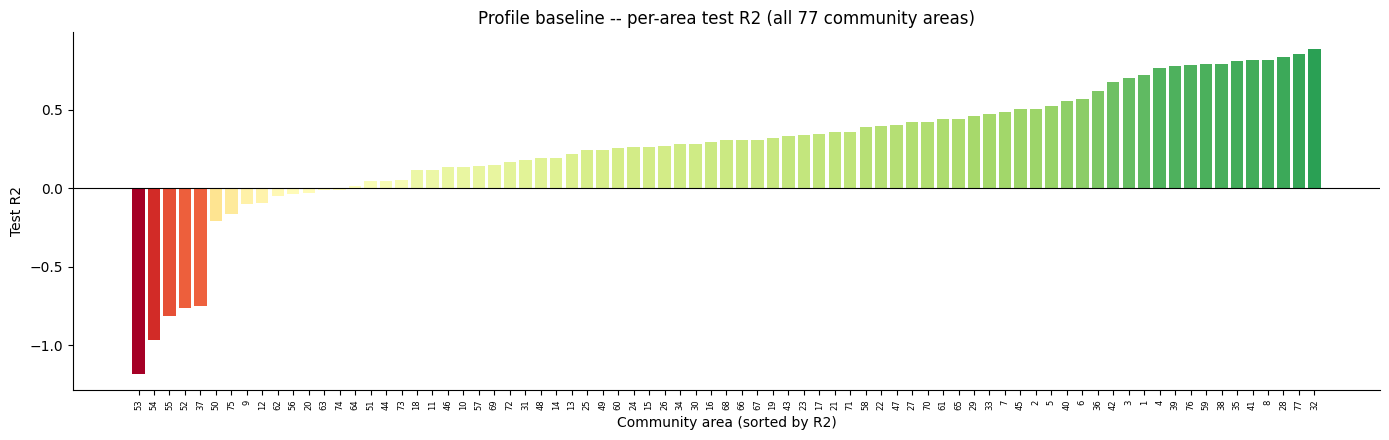

In [5]:
def profile_baseline(panel, groups, group_col="community_area"):
    results = []
    y_true_all, y_pred_all = [], []
    for g in groups:
        df_g = panel[panel[group_col] == g]
        tr = df_g[df_g["timestamp"] < TRAIN_END]
        te = df_g[df_g["timestamp"] >= TRAIN_END]
        profile = tr.groupby(["hour", "day_of_week"])["count"].mean()
        fallback = tr["count"].mean()
        keys = pd.MultiIndex.from_arrays([te["hour"], te["day_of_week"]])
        y_pred = profile.reindex(keys).fillna(fallback).to_numpy()
        y_true_ = te["count"].to_numpy(dtype=float)
        results.append({
            group_col: g,
            "median_demand": float(df_g["count"].median()),
            **metrics(y_true_, y_pred),
        })
        y_true_all.append(y_true_)
        y_pred_all.append(y_pred)
    per_group_df = pd.DataFrame(results)
    pooled = metrics(np.concatenate(y_true_all), np.concatenate(y_pred_all))
    return per_group_df, pooled


t0 = time.time()
baseline_results, pm_baseline = profile_baseline(panel, ALL_AREAS)
baseline_results["community_area"] = baseline_results["community_area"].astype(int)

print(f"Profile baseline, all 77 areas ({time.time()-t0:.0f}s)")
print(f"  Pooled  : R2={pm_baseline['r2']:.3f}  MAE={pm_baseline['mae']:.2f}  RMSE={pm_baseline['rmse']:.2f}")
print(f"  Per area: median R2={baseline_results['r2'].median():.3f}  "
      f"median MAE={baseline_results['mae'].median():.2f}  "
      f"median RMSE={baseline_results['rmse'].median():.2f}  "
      f"(areas with R2<0: {(baseline_results['r2']<0).sum()} of {len(baseline_results)})")

print("\nPer-area profile-baseline performance (sorted by R2, worst first):")
print(baseline_results.sort_values("r2").reset_index(drop=True).to_string(index=False))

# Diverging (R2 can be negative or positive) colouring, same RdYlGn scale used for the
# skill map further down, so the two figures read consistently.
plot_df = baseline_results.sort_values("r2").reset_index(drop=True)
vlim = max(0.5, plot_df["r2"].abs().max())
colors = plt.cm.RdYlGn((plot_df["r2"] + vlim) / (2 * vlim))

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.bar(range(len(plot_df)), plot_df["r2"], color=colors, width=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df["community_area"], rotation=90, fontsize=6)
ax.set_xlabel("Community area (sorted by R2)")
ax.set_ylabel("Test R2")
ax.set_title("Profile baseline -- per-area test R2 (all 77 community areas)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## 5. Census Tract Level

- `pickup_census_tract` is **not usable as an ID**: only 44.6% populated, and stored as
  `float32` — which corrupts 11-digit tract GEOIDs on rounding (`17031081700` ->
  `17031081984`). Confirmed 0% exact match against tract boundaries.
- Its *presence*, though, is still meaningful even though its value isn't: Chicago's data
  masks a trip's tract down to its parent community area's centroid whenever that tract had
  too few trips in the period (a privacy rule). So `pickup_census_tract.notna()` tells us,
  per trip, whether we have a genuinely tract-precise location or just a coarse area-level
  fallback point — this drives both the modeling scope (5.0) and how counts are built (5.2).
- **Two-layer spatial identity**: same 76 community-area dummies (via each tract's parent
  community area, `tract_comm` — no extra join needed) + tract-level covariates: POI count,
  tract area, and distance to 6 empirically-derived demand hot spots (5.1) instead of
  hand-picked landmarks.

### 5.0 Tract-Precision Coverage & Modeling Scope

- Retention of real tract IDs varies sharply by community area — from 0% (several low-volume
  areas have *zero* tract-precision trips at all) up to 70.9% (the Loop) — with a clean gap
  in the distribution between 4.85% and 7.17% and nothing in between. Areas below that gap
  have too few tract-precision trips to build any real per-tract spatial signal from (often
  single digits over the full 2-year training period) — scaling that up would just be
  scaling noise, not recovering signal.
- **`RETENTION_THRESHOLD = 0.05`**, right in that gap: community areas below it are excluded
  from tract-level modeling entirely. Their tracts have no counterpart in this notebook --
  `03.02`'s community-area model is the fallback for demand estimates there.
- This leaves **11 of 77 community areas / 179 of 878 tracts** in scope — almost exactly the
  same high-volume areas the GMM hot-spot analysis (5.1) already flagged (Loop, Near North
  Side, Near West Side, O'Hare, Garfield Ridge, plus a few more): the areas with enough
  demand to generate enough tract-precision trips are the areas the GMM already said matter
  most.
- Counts are then built from tract-precision trips **only**, never the coarse fallback
  points (5.2 explains why that matters, not just for coverage), and scaled up by each
  area's inverse retention fraction to estimate total demand rather than just the observed
  tract-precision sample.

### 5.1 Demand Hot Spots as Spatial Reference Points

- `02_gmm.ipynb` fits a 6-component Gaussian Mixture Model directly on pickup coordinates
  (`K=6`, chosen by BIC elbow) and finds those 6 components alone cover **97% of citywide
  pickup demand**. Reused here as fixed reference points for `dist_hotspotN_km` features
  below, rather than 2 hand-picked landmarks (downtown, O'Hare) — the GMM centers are
  data-derived and include hubs a landmark guess would miss (the Near West Side medical
  district/UIC cluster, a Garfield Ridge/Midway-adjacent cluster), while still keeping
  dimensionality tiny (6 continuous distances, not 878 dummies).
- The GMM is **not refit here** — its 6 component means (lat/lon) are hardcoded below from
  that notebook's already-fitted, already-validated result. Hot-spot *locations* don't need
  re-deriving per prediction notebook, only reusing.

In [6]:
CENSUS_TRACTS_PATH = "../../data/census_tracts_chicago.geojson"
POI_PATH            = "../../data/poi_chicago.geojson"

# GMM demand hot-spot centers (K=6, BIC elbow) from notebooks/02_gmm.ipynb --
# reused here rather than refit; ranked by demand share, together covering 97%
# of citywide pickup demand (see section 5.1).
GMM_HOTSPOTS_LATLON = [
    (41.8923, -87.6227),  # 1: Near North Side (River North/Streeterville) -- 36.1% of demand
    (41.8811, -87.6388),  # 2: Near West Side (medical district/UIC) -- 23.6%
    (41.9791, -87.9030),  # 3: O'Hare -- 21.0%
    (41.8744, -87.6256),  # 4: Loop -- 13.6%
    (41.8989, -87.6435),  # 5: Near North Side, secondary cluster -- 3.1%
    (41.7860, -87.7509),  # 6: Garfield Ridge (~Midway) -- 2.6%
]

# ---- 5.0: Tract-precision retention per community area (decides modeling scope) ----
# pickup_census_tract is masked to the parent community area's centroid whenever a trip's
# true tract had too few trips in that period (privacy rule) -- its presence/absence (not its
# corrupted float32 value) tells us, per trip, whether we have real intra-area location detail
# or just a coarse fallback point. This needs the FULL population (both masked and unmasked
# trips) to compute a retention rate, so no row filter applies here -- only 2 light columns.
retention_raw = pd.read_parquet(TAXI_DATA_PATH, columns=["pickup_census_tract", "pickup_community_area"])
retention_raw = retention_raw.dropna(subset=["pickup_community_area"]).copy()
retention_raw["pickup_community_area"] = retention_raw["pickup_community_area"].astype(int)
retention_raw["has_tract"] = retention_raw["pickup_census_tract"].notna()

AREA_RETENTION = retention_raw.groupby("pickup_community_area")["has_tract"].mean().rename("retention_frac")
del retention_raw

RETENTION_THRESHOLD = 0.05  # natural gap in the data: no area falls between 4.85% and 7.17%
INCLUDED_AREAS = np.sort(AREA_RETENTION[AREA_RETENTION >= RETENTION_THRESHOLD].index.to_numpy())
EXCLUDED_AREAS = np.sort(AREA_RETENTION[AREA_RETENTION < RETENTION_THRESHOLD].index.to_numpy())
AREA_SCALE_FACTOR = (1 / AREA_RETENTION).rename("scale_factor")  # inverse retention -> estimated total demand

print(f"{len(INCLUDED_AREAS)} of {len(AREA_RETENTION)} community areas retain >= "
      f"{RETENTION_THRESHOLD*100:.0f}% tract-precision trips -- in scope for tract-level modeling:")
print(f"  included: {INCLUDED_AREAS.tolist()}")
print(f"  excluded (use 03.02's community-area model instead): {EXCLUDED_AREAS.tolist()}")

# ---- Tract boundaries + covariates, restricted to included areas ----
tracts_gdf = gpd.read_file(CENSUS_TRACTS_PATH)[["census_t_1", "tract_comm", "shape_area", "geometry"]].copy()
tracts_gdf["tract_id"] = tracts_gdf["census_t_1"].astype("int64")
tracts_gdf["community_area"] = tracts_gdf["tract_comm"].astype(int)  # 0 = no official CA (9 tracts, mostly water/edge artifacts)
tracts_gdf = tracts_gdf[tracts_gdf["community_area"].isin(INCLUDED_AREAS)].copy()
tracts_gdf["tract_area"] = tracts_gdf["shape_area"].astype(float)
ALL_TRACTS = tracts_gdf["tract_id"].to_numpy()

centroids_3857 = tracts_gdf.set_geometry("geometry").to_crs(epsg=3857).geometry.centroid
hotspot_pts_3857 = gpd.GeoSeries(
    gpd.points_from_xy([lon for _, lon in GMM_HOTSPOTS_LATLON], [lat for lat, _ in GMM_HOTSPOTS_LATLON]),
    crs="EPSG:4326",
).to_crs(epsg=3857)
DIST_HOTSPOT_COLS = [f"dist_hotspot{i}_km" for i in range(1, len(GMM_HOTSPOTS_LATLON) + 1)]
for col, pt in zip(DIST_HOTSPOT_COLS, hotspot_pts_3857):
    tracts_gdf[col] = centroids_3857.distance(pt) / 1000

# POI count per tract (spatial join against the in-scope tract polygons)
poi_gdf = gpd.read_file(POI_PATH)[["geometry"]]
poi_joined = gpd.sjoin(poi_gdf, tracts_gdf[["tract_id", "geometry"]], how="left", predicate="within")
poi_counts = poi_joined.groupby("tract_id").size().rename("poi_count")
tracts_gdf = tracts_gdf.merge(poi_counts, on="tract_id", how="left")
tracts_gdf["poi_count"] = tracts_gdf["poi_count"].fillna(0)

print(f"{len(tracts_gdf)} tracts in scope (of 878 total), "
      f"{poi_joined['tract_id'].notna().mean()*100:.1f}% of {len(poi_gdf):,} POIs matched")

# ---- Taxi trips -> tract, via spatial join on TRACT-PRECISION TRIPS ONLY ----
# Trips whose tract was masked have their lat/lon replaced by the community area's centroid
# -- spatially joining those against tract polygons would place every one of them in whichever
# single tract contains that centroid point, an artificial spike 02_gmm.ipynb explicitly
# avoids for the same reason. Filtered directly at the parquet scan (pyarrow predicate
# pushdown on pickup_census_tract validity + pickup_community_area membership) rather than
# reading all 14.4M rows and dropping ~87% of them afterward in pandas -- only tract-precision
# rows in included areas are ever materialized.
taxi_dataset = ds.dataset(TAXI_DATA_PATH, format="parquet")
taxi_filter = ds.field("pickup_census_tract").is_valid() & ds.field("pickup_community_area").isin(INCLUDED_AREAS)
taxi_t = taxi_dataset.to_table(
    columns=["trip_start_timestamp", "pickup_centroid_latitude", "pickup_centroid_longitude"],
    filter=taxi_filter,
).to_pandas()
n_raw_t = taxi_dataset.count_rows()  # metadata-only, doesn't scan the data
taxi_t = taxi_t.dropna(subset=["pickup_centroid_latitude", "pickup_centroid_longitude"]).copy()

taxi_gdf = gpd.GeoDataFrame(
    taxi_t, geometry=gpd.points_from_xy(taxi_t["pickup_centroid_longitude"], taxi_t["pickup_centroid_latitude"]), crs="EPSG:4326",
)
taxi_t = gpd.sjoin(taxi_gdf, tracts_gdf[["tract_id", "geometry"]], how="left", predicate="within")
taxi_t = pd.DataFrame(taxi_t.drop(columns="geometry")).dropna(subset=["tract_id"]).copy()
taxi_t["tract_id"] = taxi_t["tract_id"].astype("int64")

print(f"Tract-precision trips in included areas: {len(taxi_t):,} of {n_raw_t:,} total trips "
      f"({len(taxi_t)/n_raw_t*100:.1f}%), covering {taxi_t['tract_id'].nunique()} of "
      f"{len(ALL_TRACTS)} in-scope tracts. These raw counts are scaled up per area in 5.2 to "
      f"estimate total demand (retention within included areas still averages only "
      f"{AREA_RETENTION.loc[INCLUDED_AREAS].mean()*100:.0f}%).")

11 of 77 community areas retain >= 5% tract-precision trips -- in scope for tract-level modeling:
  included: [3, 6, 7, 8, 28, 32, 33, 41, 56, 59, 76]
  excluded (use 03.02's community-area model instead): [1, 2, 4, 5, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30, 31, 34, 35, 36, 37, 38, 39, 40, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 57, 58, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 77]
179 tracts in scope (of 878 total), 50.2% of 82,114 POIs matched
Tract-precision trips in included areas: 6,423,800 of 14,465,650 total trips (44.4%), covering 125 of 179 in-scope tracts. These raw counts are scaled up per area in 5.2 to estimate total demand (retention within included areas still averages only 37%).


### 5.1.1 Map: Tracts In Scope

Visual complement to 5.0's numbers -- which tracts get a tract-level model at all. Reloads
the full 878-tract boundary file fresh (not the already-filtered `tracts_gdf`) so the
excluded tracts are visible too, not just absent.

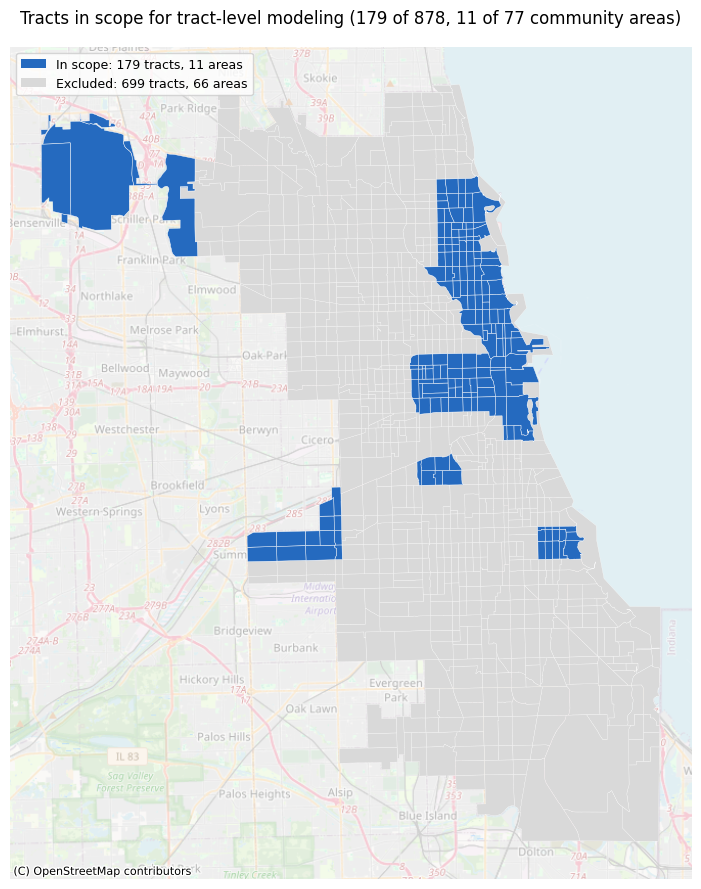

In [7]:
all_tracts_gdf = gpd.read_file(CENSUS_TRACTS_PATH)[["census_t_1", "tract_comm", "geometry"]].copy()
all_tracts_gdf["tract_id"] = all_tracts_gdf["census_t_1"].astype("int64")
all_tracts_gdf["community_area"] = all_tracts_gdf["tract_comm"].astype(int)
all_tracts_gdf["in_scope"] = all_tracts_gdf["community_area"].isin(INCLUDED_AREAS)
all_tracts_gdf = all_tracts_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(9, 9))
all_tracts_gdf[~all_tracts_gdf["in_scope"]].plot(ax=ax, color="#d9d9d9", edgecolor="white", linewidth=0.2)
all_tracts_gdf[all_tracts_gdf["in_scope"]].plot(ax=ax, color=SEQUENTIAL_BLUE, edgecolor="white", linewidth=0.3)
ctx.add_basemap(ax, crs=all_tracts_gdf.crs, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.35)
ax.set_title(f"Tracts in scope for tract-level modeling ({len(ALL_TRACTS)} of 878, "
             f"{len(INCLUDED_AREAS)} of 77 community areas)")
legend_handles = [
    Patch(facecolor=SEQUENTIAL_BLUE, label=f"In scope: {len(ALL_TRACTS)} tracts, {len(INCLUDED_AREAS)} areas"),
    Patch(facecolor="#d9d9d9", label=f"Excluded: {878 - len(ALL_TRACTS)} tracts, {77 - len(INCLUDED_AREAS)} areas"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=9)
ax.axis("off")
plt.tight_layout()
plt.show()

### 5.2 Building the Tract Panel

- Same zero-filled grid as section 2, keyed on `tract_id`, but restricted to the 179
  in-scope tracts from 5.0 (not all 878).
- Counts come from **tract-precision trips only** (`pickup_census_tract.notna()`). Trips
  whose tract was masked have their lat/lon replaced by the community area's centroid — if
  those were spatially joined against tract polygons like the precise trips, every one of
  them would land in whichever single tract contains that centroid point, creating an
  artificial demand spike there (the same distortion `02_gmm.ipynb` excludes CA-only trips
  to avoid). Excluding them keeps the *shape* of each tract's demand correct; the resulting
  undercount is then corrected by the per-area scale factor from 5.0.
- Merges in parent community area (same 76 dummies) + tract covariates (POI count and tract
  area log-transformed — heavily skewed, same treatment as the demand target — plus the 6
  GMM hot-spot distances from 5.1).

In [8]:
window_t = taxi_t["trip_start_timestamp"].dt.floor(FREQ).rename("timestamp")
counts_t = taxi_t.groupby(["tract_id", window_t]).size().rename("count")

grid_t = pd.MultiIndex.from_product([ALL_TRACTS, all_windows], names=["tract_id", "timestamp"])
panel_t = counts_t.reindex(grid_t, fill_value=0).reset_index()
panel_t = panel_t.merge(w_agg, on="timestamp", how="left")  # w_agg from section 2 -- weather doesn't depend on resolution

panel_t["hour"]        = panel_t["timestamp"].dt.hour
panel_t["day_of_week"] = panel_t["timestamp"].dt.dayofweek
month_t                = panel_t["timestamp"].dt.month

panel_t["hour_sin"]         = np.sin(2 * np.pi * panel_t["hour"] / 24)
panel_t["hour_cos"]         = np.cos(2 * np.pi * panel_t["hour"] / 24)
panel_t["hour_sin2"]        = np.sin(4 * np.pi * panel_t["hour"] / 24)
panel_t["hour_cos2"]        = np.cos(4 * np.pi * panel_t["hour"] / 24)
panel_t["day_of_week_sin"]  = np.sin(2 * np.pi * panel_t["day_of_week"] / 7)
panel_t["day_of_week_cos"]  = np.cos(2 * np.pi * panel_t["day_of_week"] / 7)
panel_t["day_of_week_sin2"] = np.sin(4 * np.pi * panel_t["day_of_week"] / 7)
panel_t["day_of_week_cos2"] = np.cos(4 * np.pi * panel_t["day_of_week"] / 7)
panel_t["month_sin"]        = np.sin(2 * np.pi * month_t / 12)
panel_t["month_cos"]        = np.cos(2 * np.pi * month_t / 12)
panel_t["is_weekend"]       = (panel_t["day_of_week"] >= 5).astype(int)
panel_t["is_holiday"]       = panel_t["timestamp"].dt.date.isin(US_HOLIDAYS.date).astype(int)

# tract-level covariates + parent community area
panel_t = panel_t.merge(
    tracts_gdf[["tract_id", "community_area", "tract_area", "poi_count", *DIST_HOTSPOT_COLS]],
    on="tract_id", how="left",
)
panel_t["poi_count_log"]  = np.log1p(panel_t["poi_count"])
panel_t["tract_area_log"] = np.log1p(panel_t["tract_area"])

# Scale observed tract-precision counts up to estimate total demand (section 5.0): an area
# retaining only e.g. 30% of its trips at tract precision means each trip counted here
# "stands in" for ~1/0.30 real trips -- the same inverse-probability weighting a survey uses
# to correct for non-uniform sampling. `count` becomes this scaled estimate everywhere
# downstream (target, metrics, baseline); `count_observed` keeps the raw tract-precision
# count for reference.
panel_t["count_observed"] = panel_t["count"]
panel_t["count"] = panel_t["count_observed"] * panel_t["community_area"].map(AREA_SCALE_FACTOR)

# Community-area fixed effects: every tract here already belongs to one of the 11 included,
# valid community areas (excluded-area and no-CA tracts were dropped when tracts_gdf was
# built in 5.0), so no NaN-masking is needed -- get_dummies still emits all 76 columns
# because `categories=ALL_AREAS` fixes the dummy set regardless of which areas are observed.
dummies_t = pd.get_dummies(pd.Categorical(panel_t["community_area"], categories=ALL_AREAS), prefix="area", drop_first=True).astype(float)
assert list(dummies_t.columns) == DUMMY_COLS  # exact same 76 columns as the community-area panel
panel_t = pd.concat([panel_t, dummies_t], axis=1)

panel_t = panel_t.sort_values(["tract_id", "timestamp"]).reset_index(drop=True)
print(f"{FREQ}: {len(panel_t):,} rows ({panel_t['tract_id'].nunique()} tracts x "
      f"{panel_t['timestamp'].nunique():,} windows), zero-demand windows: {(panel_t['count']==0).mean()*100:.1f}%")

4h: 947,268 rows (179 tracts x 5,292 windows), zero-demand windows: 85.5%


### 5.3 Feature Set & Train/Test Split (Tract Level)

- Same 17 time/weather features + same 76 community-area dummies (unscaled), plus 8
  tract-level covariates (POI count, tract area, distance to each of the 6 GMM demand hot
  spots from 5.1), over the 179 in-scope tracts (5.0).

In [9]:
FEATURE_COLS_TRACT = FEATURE_COLS + ["poi_count_log", "tract_area_log"] + DIST_HOTSPOT_COLS
ALL_COLS_TRACT = FEATURE_COLS_TRACT + DUMMY_COLS

preprocess_tract = ColumnTransformer([
    ("scale", StandardScaler(), FEATURE_COLS_TRACT),
    ("area_dummies", "passthrough", DUMMY_COLS),
])

train_tract = panel_t[panel_t["timestamp"] < TRAIN_END]
test_tract  = panel_t[panel_t["timestamp"] >= TRAIN_END]
y_true_tract = test_tract["count"].to_numpy(dtype=float)
print(f"train={len(train_tract):,} rows   test={len(test_tract):,} rows  "
      f"(~{len(train_tract)/len(train):.1f}x the community-area training set)")

train=785,094 rows   test=162,174 rows  (~2.3x the community-area training set)


### 5.4 Profile Baseline (Tract Level)

- Same construction as section 4, `group_col="tract_id"`.
- Expect it to look different in aggregate: 179 units spread the same (scaled-up) demand
  thinner than 77 community areas do, so more units sit in the near-zero regime (noisier R2,
  MAE rounds to ~0) -- even though this is a small, high-volume subset of all 878 tracts, not
  the full long tail.

Profile baseline, 179 in-scope tracts (2s)
  Pooled   : R2=0.860  MAE=5.63  RMSE=25.18
  Per tract: median R2=0.170  median MAE=0.15  median RMSE=1.11  (tracts with R2<0: 38 of 179)


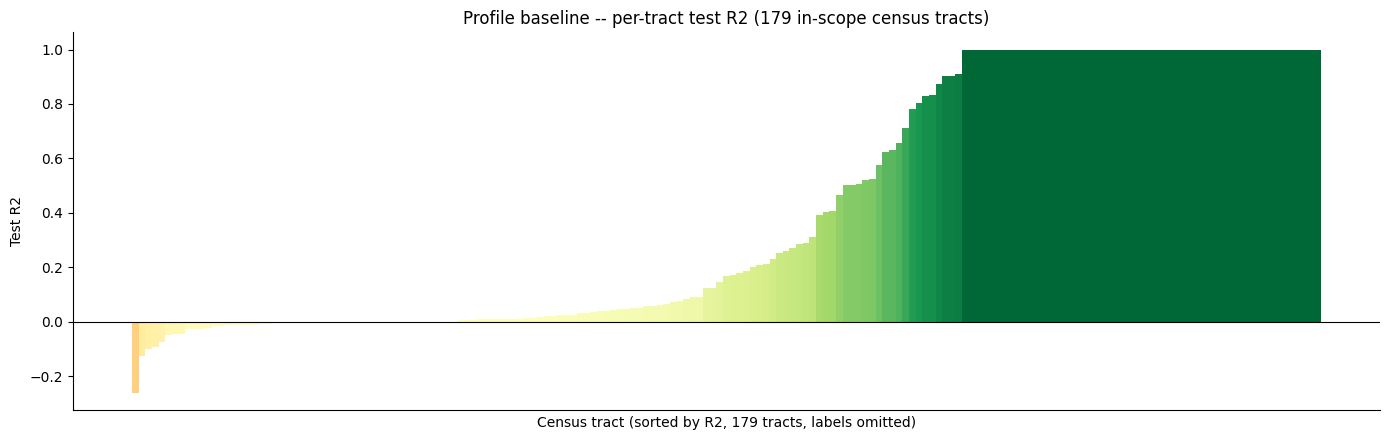

In [10]:
t0 = time.time()
baseline_results_tract, pm_baseline_tract = profile_baseline(panel_t, ALL_TRACTS, group_col="tract_id")

print(f"Profile baseline, {len(ALL_TRACTS)} in-scope tracts ({time.time()-t0:.0f}s)")
print(f"  Pooled   : R2={pm_baseline_tract['r2']:.3f}  MAE={pm_baseline_tract['mae']:.2f}  RMSE={pm_baseline_tract['rmse']:.2f}")
print(f"  Per tract: median R2={baseline_results_tract['r2'].median():.3f}  "
      f"median MAE={baseline_results_tract['mae'].median():.2f}  "
      f"median RMSE={baseline_results_tract['rmse'].median():.2f}  "
      f"(tracts with R2<0: {(baseline_results_tract['r2']<0).sum()} of {len(baseline_results_tract)})")

# Same diverging-R2 bar chart as section 4, but with 179 units instead of 77 the individual
# x-tick labels would be illegible, so the axis is left unlabeled -- the point of this chart is
# the shape of the distribution (how much of it sits below zero), not any single tract's value.
plot_df_t = baseline_results_tract.sort_values("r2").reset_index(drop=True)
vlim_t = max(0.5, plot_df_t["r2"].abs().max())
colors_t = plt.cm.RdYlGn((plot_df_t["r2"] + vlim_t) / (2 * vlim_t))

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.bar(range(len(plot_df_t)), plot_df_t["r2"], color=colors_t, width=1.0)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks([])
ax.set_xlabel(f"Census tract (sorted by R2, {len(plot_df_t)} tracts, labels omitted)")
ax.set_ylabel("Test R2")
ax.set_title("Profile baseline -- per-tract test R2 (179 in-scope census tracts)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 5.4.1 Baseline Performance — Top Tracts

Same style as section 4's community-area baseline check: actual vs. predicted for the
top-3 in-scope tracts (by median demand in the eval week), one eval week from the test set.
`profile_baseline_predict` below is a vectorized, row-aligned version of the
`profile_baseline` logic above -- reused again in 5.7.0/5.7.2 for the full test set, not
just this eval week.

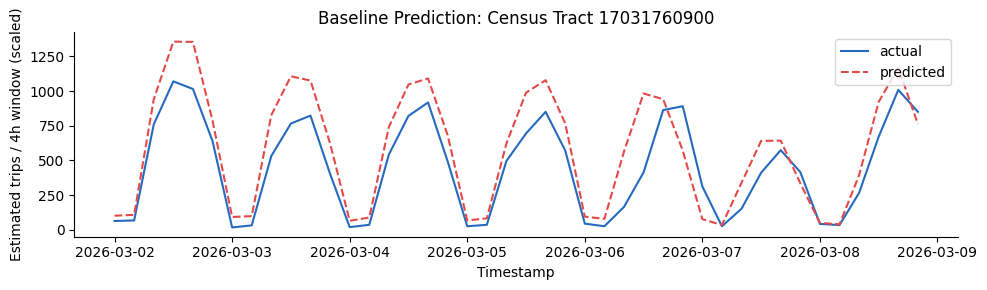

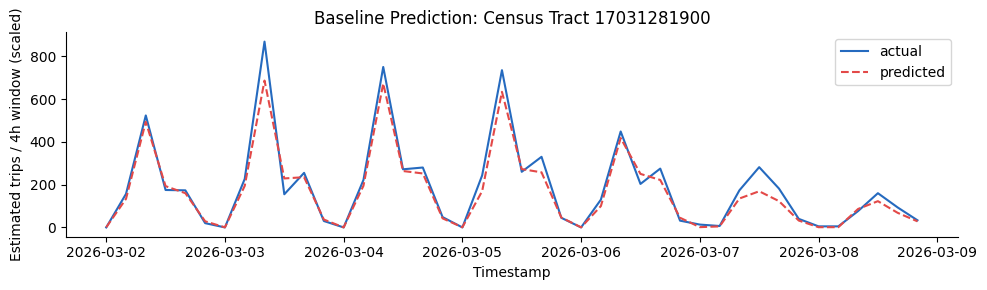

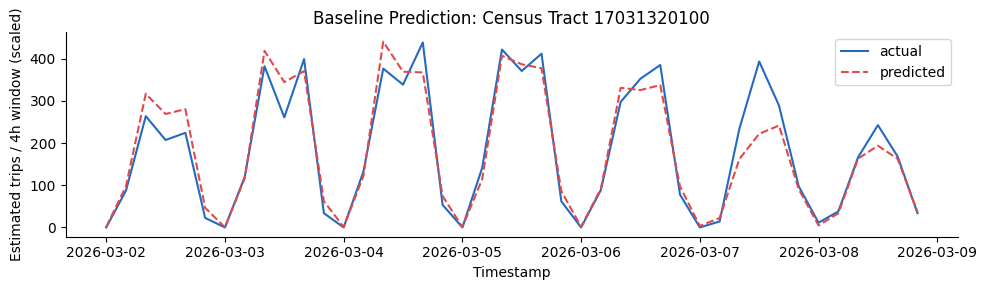

In [11]:
def profile_baseline_predict(panel, test_df, group_col="tract_id"):
    """Row-aligned profile-baseline predictions for test_df: train-set mean per
    (group_col, hour, day_of_week), reindexed onto test_df's own keys -- safe regardless of
    group order (unlike concatenating a per-group loop, which only lines up with test_df if
    groups happen to be iterated and sorted identically -- not guaranteed for tract_id)."""
    train_df = panel[panel["timestamp"] < TRAIN_END]
    profile = train_df.groupby([group_col, "hour", "day_of_week"])["count"].mean()
    fallback = train_df.groupby(group_col)["count"].mean()
    keys = pd.MultiIndex.from_arrays([test_df[group_col], test_df["hour"], test_df["day_of_week"]])
    y_pred = profile.reindex(keys).to_numpy()
    missing = np.isnan(y_pred)
    if missing.any():
        y_pred[missing] = test_df[group_col].map(fallback).to_numpy()[missing]
    return y_pred


baseline_y_pred_tract = profile_baseline_predict(panel_t, test_tract, group_col="tract_id")

# Same eval_mask/test_plot convention as 03.02 section 4.1 -- reused again in 5.7.2.
eval_mask_t = (test_tract["timestamp"] >= EVAL_WEEK_START) & (test_tract["timestamp"] < EVAL_WEEK_END)
test_plot_t = test_tract[eval_mask_t].reset_index(drop=True)
test_plot_pred_base_t = baseline_y_pred_tract[eval_mask_t.to_numpy()]

# Top-3 only (not bottom-3 like the community-area notebooks): at tract level the
# lowest-demand in-scope tracts are close enough to zero that a bottom-3 chart would mostly
# show flat lines -- not informative the way it is at community-area resolution.
top_3_tracts = test_plot_t.groupby("tract_id")["count"].median().sort_values(ascending=False).head(3).index

for tract in top_3_tracts:
    mask = (test_plot_t["tract_id"] == tract).to_numpy()
    area_val = test_plot_t[mask]
    area_pred = test_plot_pred_base_t[mask]

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(area_val["timestamp"], area_val["count"], label="actual", color=SEQUENTIAL_BLUE)
    ax.plot(area_val["timestamp"], area_pred, label="predicted", color="#e34948", linestyle="--")
    ax.set_title(f"Baseline Prediction: Census Tract {tract}")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Estimated trips / 4h window (scaled)")
    ax.legend(loc="upper right")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

### 5.5 Pooled LinearSVR — Tract Level, Full Data

Per the decision in `03.01`: `LinearSVR` on the full tract training set, no subsampling --
the primary SVM entry at this resolution. No repeated `GridSearchCV` pass.

In [12]:
t0 = time.time()
linear_model_tract = Pipeline([
    ("prep", preprocess_tract),
    ("svm", LinearSVR(C=1.0, epsilon=0.1, max_iter=20000, random_state=42)),
])
linear_model_tract.fit(train_tract[ALL_COLS_TRACT], np.log1p(train_tract["count"]))
y_pred_linear_tract = predict_counts(linear_model_tract, test_tract[ALL_COLS_TRACT])
pm_linear_tract = metrics(y_true_tract, y_pred_linear_tract)
res_linear_tract = per_area_results(test_tract, y_pred_linear_tract, group_col="tract_id")
res_linear_tract["skill"] = skill_vs_baseline(res_linear_tract, baseline_df=baseline_results_tract, group_col="tract_id")

TRACT_MEDIAN_DEMAND = panel_t.groupby("tract_id")["count"].median().rename("median_demand")

# Train-period mean demand per tract -- same convention as the community-area notebooks
# (mean, not median, unlike TRACT_MEDIAN_DEMAND above), so weighted_rmse is directly
# comparable across resolutions and against the NN notebooks.
TRACT_UNIT_WEIGHT = train_tract.groupby("tract_id")["count"].mean()
TEST_TRACT_UNIT_WEIGHTS = test_tract["tract_id"].map(TRACT_UNIT_WEIGHT).fillna(TRACT_UNIT_WEIGHT.mean()).to_numpy()

print_pooled_results(
    f"Pooled LinearSVR, tract level ({time.time()-t0:.0f}s)", pm_linear_tract, res_linear_tract,
    baseline_df=baseline_results_tract, median_demand=TRACT_MEDIAN_DEMAND, group_col="tract_id",
    weighted_rmse_value=weighted_rmse(y_true_tract, y_pred_linear_tract, TEST_TRACT_UNIT_WEIGHTS),
)

Pooled LinearSVR, tract level (1098s)
  Pooled       : R2=0.026  MAE=13.12  RMSE=66.39  (sanity check only)
  Weighted RMSE: 355.19  (headline)
  Skill        : demand-weighted (headline)=+nan  unweighted median=-0.259  median R2=-0.009  (areas with negative skill: 90 of 179)


/Users/maikekatterbach/Documents/GitHub/AAA_Team_1/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:592: RuntimeWarning: invalid value encountered in multiply
  avg = avg_as_array = np.multiply(a, wgt,


### 5.5.1 Feature Importance (LinearSVR Coefficients)

- Same interpretation as `03.01`/`03.02`: coefficients on the standardized continuous
  features are directly comparable as feature importance; area-dummy coefficients are a
  separate log-demand offset per area, not shown here -- already covered at community-area
  resolution, and there'd be 76 of them.
- Specifically highlights the 6 GMM hotspot-distance features (5.1) against the other 19
  continuous features, plus a group-level summary (weather / time-calendar / tract-shape+POI
  / GMM hotspots) -- a single-feature ranking can hide whether a *group* matters if its
  importance is split across several correlated features.

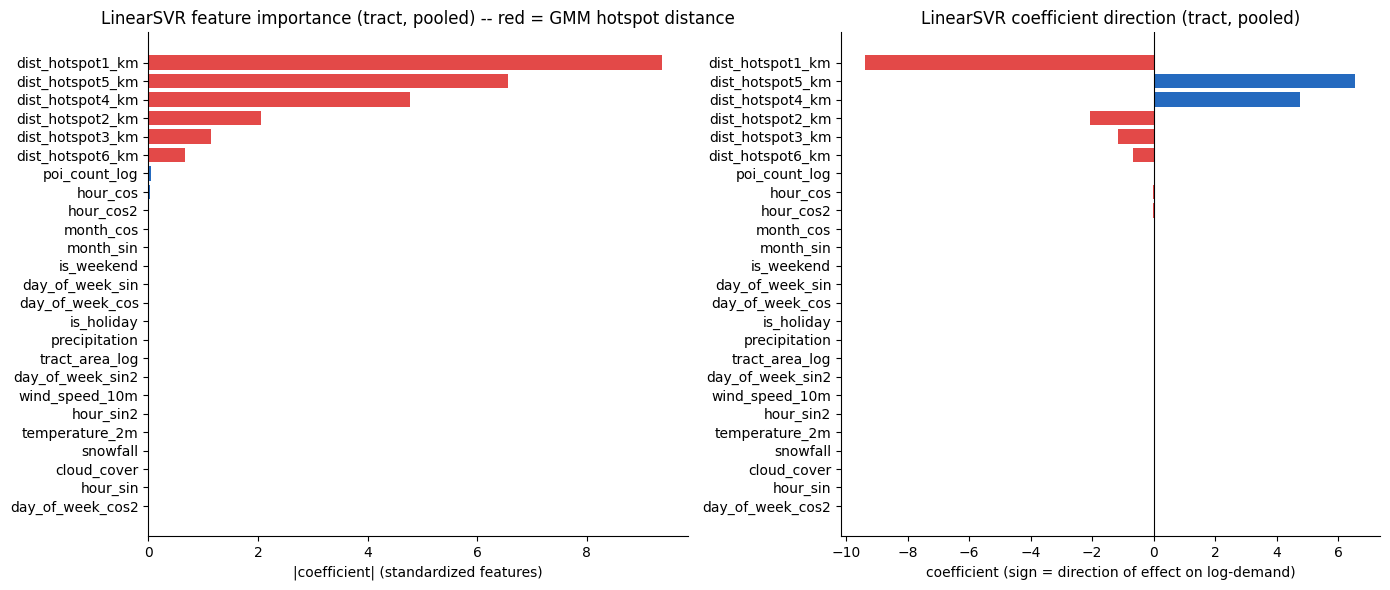

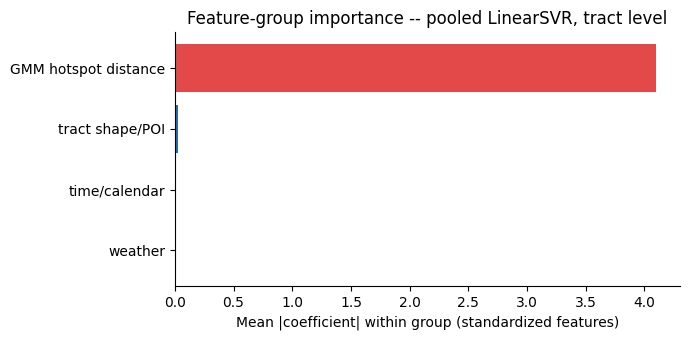

GMM hotspot distances: 99.6% of total |coefficient| mass across all 25 continuous features (vs. 6/25 = 24.0% of features -- so a share above that number means hotspot distances punch above their weight, and below means the reverse).

GMM hotspot distance coefficients, ranked by |coefficient|:
         feature  coefficient  importance
dist_hotspot1_km    -9.374548    9.374548
dist_hotspot5_km     6.566409    6.566409
dist_hotspot4_km     4.776878    4.776878
dist_hotspot2_km    -2.058054    2.058054
dist_hotspot3_km    -1.145359    1.145359
dist_hotspot6_km    -0.666379    0.666379


In [13]:
coefs_tract = linear_model_tract.named_steps["svm"].coef_
feature_coefs_tract = pd.DataFrame({
    "feature": FEATURE_COLS_TRACT,
    "coefficient": coefs_tract[:len(FEATURE_COLS_TRACT)],
    "importance": np.abs(coefs_tract[:len(FEATURE_COLS_TRACT)]),
}).sort_values("importance")
feature_coefs_tract["is_hotspot"] = feature_coefs_tract["feature"].isin(DIST_HOTSPOT_COLS)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
bar_colors_imp = ["#e34948" if h else SEQUENTIAL_BLUE for h in feature_coefs_tract["is_hotspot"]]
axes[0].barh(feature_coefs_tract["feature"], feature_coefs_tract["importance"], color=bar_colors_imp)
axes[0].set_xlabel("|coefficient| (standardized features)")
axes[0].set_title("LinearSVR feature importance (tract, pooled) -- red = GMM hotspot distance")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].barh(feature_coefs_tract["feature"], feature_coefs_tract["coefficient"],
             color=[SEQUENTIAL_BLUE if c >= 0 else "#e34948" for c in feature_coefs_tract["coefficient"]])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("coefficient (sign = direction of effect on log-demand)")
axes[1].set_title("LinearSVR coefficient direction (tract, pooled)")
axes[1].spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Group-level summary: does the GMM hotspot-distance group matter, relative to weather,
# time/calendar, and the tract-shape/POI covariates?
FEATURE_GROUPS_TRACT = {
    "weather": ["temperature_2m", "precipitation", "snowfall", "wind_speed_10m", "cloud_cover"],
    "time/calendar": ["hour_sin", "hour_cos", "hour_sin2", "hour_cos2",
                       "day_of_week_sin", "day_of_week_cos", "day_of_week_sin2", "day_of_week_cos2",
                       "month_sin", "month_cos", "is_weekend", "is_holiday"],
    "tract shape/POI": ["poi_count_log", "tract_area_log"],
    "GMM hotspot distance": DIST_HOTSPOT_COLS,
}
group_importance = pd.Series({
    group: feature_coefs_tract.set_index("feature").loc[cols, "importance"].mean()
    for group, cols in FEATURE_GROUPS_TRACT.items()
}).sort_values()

fig, ax = plt.subplots(figsize=(7, 3.5))
group_colors = ["#e34948" if g == "GMM hotspot distance" else SEQUENTIAL_BLUE for g in group_importance.index]
ax.barh(group_importance.index, group_importance.to_numpy(), color=group_colors)
ax.set_xlabel("Mean |coefficient| within group (standardized features)")
ax.set_title("Feature-group importance -- pooled LinearSVR, tract level")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

hotspot_share = (
    feature_coefs_tract.loc[feature_coefs_tract["is_hotspot"], "importance"].sum()
    / feature_coefs_tract["importance"].sum()
)
print(f"GMM hotspot distances: {hotspot_share*100:.1f}% of total |coefficient| mass across "
      f"all {len(FEATURE_COLS_TRACT)} continuous features (vs. {len(DIST_HOTSPOT_COLS)}/"
      f"{len(FEATURE_COLS_TRACT)} = {len(DIST_HOTSPOT_COLS)/len(FEATURE_COLS_TRACT)*100:.1f}% "
      f"of features -- so a share above that number means hotspot distances punch above "
      f"their weight, and below means the reverse).")
print("\nGMM hotspot distance coefficients, ranked by |coefficient|:")
print(feature_coefs_tract[feature_coefs_tract["is_hotspot"]]
      .sort_values("importance", ascending=False)[["feature", "coefficient", "importance"]]
      .to_string(index=False))

### 5.6 Lightweight Kernel Snapshot — Documentation Only

- One subsample, no tuning -- checks whether `03.01` section 7's instability persists at
  tract scale.
- Not a model-selection step; `LinearSVR` remains the credible SVM entry regardless.

In [14]:
rng_tract = np.random.RandomState(42)
# 10,000 rows, matching the subsample size used everywhere else this snapshot pattern
# appears (03.01, 03.02) -- this section is documentation only (checks whether kernel
# instability persists at tract scale), not model selection, so it doesn't need a larger
# subsample. 20,000 rows made this cell take multiples of the ~23 min the 10k version takes
# in 03.02, with no payoff (kernel SVR training cost is superlinear in row count).
sub_idx_tract = rng_tract.choice(train_tract.index, size=10000, replace=False)
train_sub_tract = train_tract.loc[sub_idx_tract]

candidates_tract = {
    "no kernel (LinearSVR)": LinearSVR(C=1.0, epsilon=0.1, max_iter=20000, random_state=42),
    "linear (SVR)":          SVR(kernel="linear",  C=100, epsilon=0.1),
    "poly, degree 2":        SVR(kernel="poly",    degree=2, C=100, gamma="scale", epsilon=0.1),
    "rbf":                   SVR(kernel="rbf",     C=100, gamma="scale", epsilon=0.1),
    "sigmoid":               SVR(kernel="sigmoid", C=100, gamma="scale", epsilon=0.1),
}
kernel_rows_tract = []
print(f"Kernel snapshot -- {sub_idx_tract.size:,}-row train subsample "
      f"({sub_idx_tract.size/len(train_tract)*100:.2f}% of {len(train_tract):,} tract-level "
      f"training rows), full test set, pooled metrics (fitting one at a time, printed as "
      f"each finishes):")
for name, svm in candidates_tract.items():
    t0 = time.time()
    m = Pipeline([("prep", preprocess_tract), ("svm", svm)])
    m.fit(train_sub_tract[ALL_COLS_TRACT], np.log1p(train_sub_tract["count"]))
    y_pred = predict_counts(m, test_tract[ALL_COLS_TRACT])
    row = {"kernel": name, **metrics(y_true_tract, y_pred), "fit_seconds": round(time.time() - t0, 1)}
    kernel_rows_tract.append(row)
    print(f"  {name:22s}  r2={row['r2']:.4f}  mae={row['mae']:.2f}  rmse={row['rmse']:.2f}  "
          f"({row['fit_seconds']:.1f}s)")

kernel_df_tract = pd.DataFrame(kernel_rows_tract).sort_values("r2", ascending=False)
print("\nRanked by R2:")
print(kernel_df_tract.to_string(index=False))

Kernel snapshot -- 10,000-row train subsample (1.27% of 785,094 tract-level training rows), full test set, pooled metrics (fitting one at a time, printed as each finishes):
  no kernel (LinearSVR)   r2=0.0293  mae=13.11  rmse=66.27  (3.3s)
  linear (SVR)            r2=0.0431  mae=13.03  rmse=65.79  (772.4s)
  poly, degree 2          r2=0.5941  mae=9.23  rmse=42.85  (162.1s)
  rbf                     r2=-1.2913  mae=11.61  rmse=101.81  (213.4s)
  sigmoid                 r2=-25906798668133.5312  mae=241719857.12  rmse=342334334.62  (106.9s)

Ranked by R2:
               kernel            r2          mae         rmse  fit_seconds
       poly, degree 2  5.941000e-01         9.23        42.85        162.1
         linear (SVR)  4.310000e-02        13.03        65.79        772.4
no kernel (LinearSVR)  2.930000e-02        13.11        66.27          3.3
                  rbf -1.291300e+00        11.61       101.81        213.4
              sigmoid -2.590680e+13 241719857.12 342334334.62    

### 5.7 Results — Tract-Level Comparison

- Two candidates: profile baseline and pooled `LinearSVR` -- demand-tiered and per-area
  variants don't apply here (`03.02`'s decisions carry over), and the kernel snapshot (5.6)
  stays documentation-only, not a third candidate.
- 5.7.0 (actual vs. predicted scatter), 5.7.1 (per-tract skill views + map), and 5.7.2
  (top-3 tracts, both models overlaid) mirror `03.02` section 8's structure at tract
  resolution.

Two headline metrics: demand-weighted skill (relative to baseline, comparable across
resolutions) and weighted RMSE (absolute trips/window, comparable against the NN
notebooks).
                           Model  Demand-weighted skill  Median skill  Weighted RMSE  Pooled R2  Median R2/tract
        Profile baseline (tract)                    0.0         0.000        132.827      0.860            0.170
LinearSVR (full data, no kernel)                    NaN        -0.259        355.192      0.026           -0.008


/Users/maikekatterbach/Documents/GitHub/AAA_Team_1/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:592: RuntimeWarning: invalid value encountered in multiply
  avg = avg_as_array = np.multiply(a, wgt,


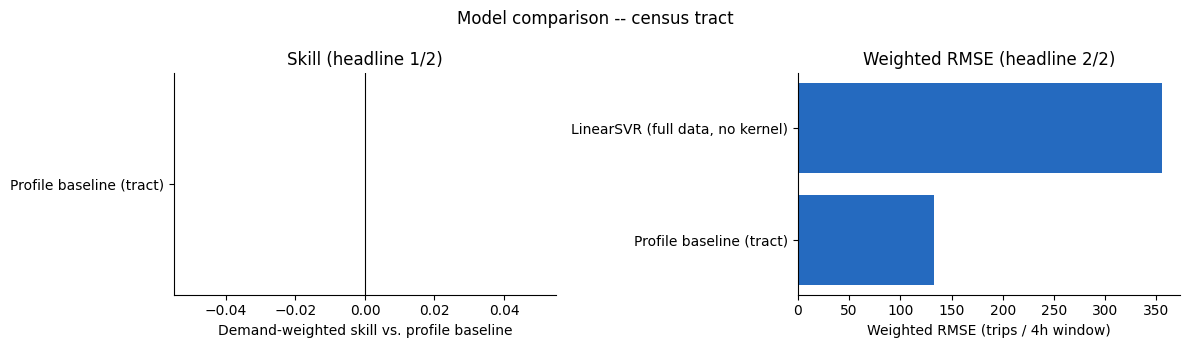

In [15]:
comparison_df_tract = pd.DataFrame([
    {"Model": "Profile baseline (tract)", "Demand-weighted skill": 0.000, "Median skill": 0.000,
     "Weighted RMSE": weighted_rmse(y_true_tract, baseline_y_pred_tract, TEST_TRACT_UNIT_WEIGHTS),
     "Pooled R2": pm_baseline_tract["r2"], "Median R2/tract": baseline_results_tract["r2"].median()},
    {"Model": "LinearSVR (full data, no kernel)",
     "Demand-weighted skill": weighted_skill_vs_baseline(
         res_linear_tract, baseline_df=baseline_results_tract, median_demand=TRACT_MEDIAN_DEMAND, group_col="tract_id"),
     "Median skill": res_linear_tract["skill"].median(),
     "Weighted RMSE": weighted_rmse(y_true_tract, y_pred_linear_tract, TEST_TRACT_UNIT_WEIGHTS),
     "Pooled R2": pm_linear_tract["r2"], "Median R2/tract": res_linear_tract["r2"].median()},
]).round(3)
print("Two headline metrics: demand-weighted skill (relative to baseline, comparable across")
print("resolutions) and weighted RMSE (absolute trips/window, comparable against the NN")
print("notebooks).")
print(comparison_df_tract.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
chart_df_t = comparison_df_tract.set_index("Model")["Demand-weighted skill"]
colors_cmp_t = [SEQUENTIAL_BLUE if v >= 0 else "#e34948" for v in chart_df_t]
axes[0].barh(chart_df_t.index, chart_df_t.to_numpy(), color=colors_cmp_t)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Demand-weighted skill vs. profile baseline")
axes[0].set_title("Skill (headline 1/2)")
axes[0].spines[["top", "right"]].set_visible(False)

wrmse_df_t = comparison_df_tract.set_index("Model")["Weighted RMSE"]
axes[1].barh(wrmse_df_t.index, wrmse_df_t.to_numpy(), color=SEQUENTIAL_BLUE)
axes[1].set_xlabel("Weighted RMSE (trips / 4h window)")
axes[1].set_title("Weighted RMSE (headline 2/2)")
axes[1].spines[["top", "right"]].set_visible(False)
plt.suptitle("Model comparison -- census tract")
plt.tight_layout()
plt.show()

### 5.7.0 Actual vs. Predicted (Test Set)

Same style as section 8.0's community-area chart -- baseline and `LinearSVR`, same test
set, `log1p` scale, 5,000-point random sample.

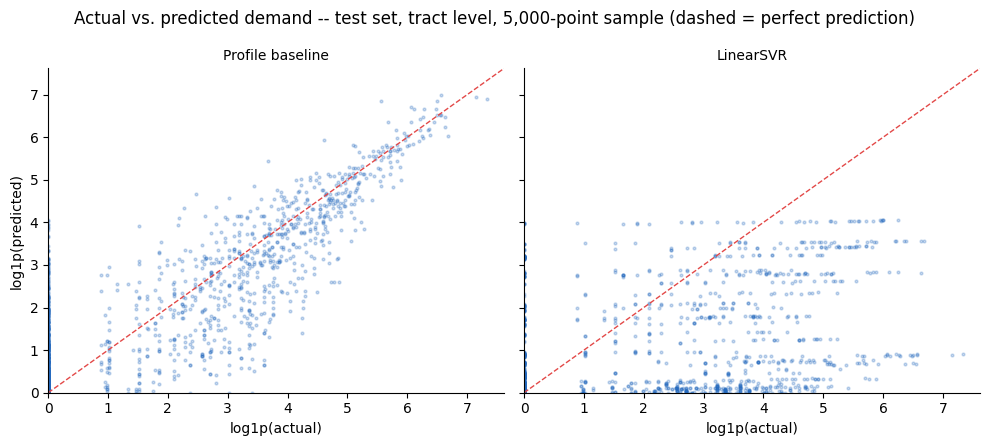

In [16]:
models_to_plot_tract = [
    ("Profile baseline", baseline_y_pred_tract),
    ("LinearSVR", y_pred_linear_tract),
]

rng_viz_t = np.random.RandomState(0)
sample_n_t = min(5000, len(y_true_tract))
sample_idx_t = rng_viz_t.choice(len(y_true_tract), size=sample_n_t, replace=False)
log_true_t = np.log1p(y_true_tract)
lims_t = [0, log_true_t.max()]

fig, axes = plt.subplots(1, len(models_to_plot_tract), figsize=(10, 4.5), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, models_to_plot_tract):
    log_pred = np.log1p(y_pred)
    ax.scatter(log_true_t[sample_idx_t], log_pred[sample_idx_t], s=4, alpha=0.25, color=SEQUENTIAL_BLUE)
    ax.plot(lims_t, lims_t, color="#e34948", linewidth=1, linestyle="--")
    ax.set_xlim(lims_t)
    ax.set_ylim(lims_t)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("log1p(actual)")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("log1p(predicted)")
plt.suptitle(f"Actual vs. predicted demand -- test set, tract level, {sample_n_t:,}-point sample "
             f"(dashed = perfect prediction)")
plt.tight_layout()
plt.show()

### 5.7.1 Per-Tract Performance

Same two complementary views as section 8.1: a sorted skill chart (x-tick labels omitted --
179 tracts, same reasoning as 5.4's baseline R2 chart) and skill vs. tract demand, for the
pooled `LinearSVR`, plus the skill map.

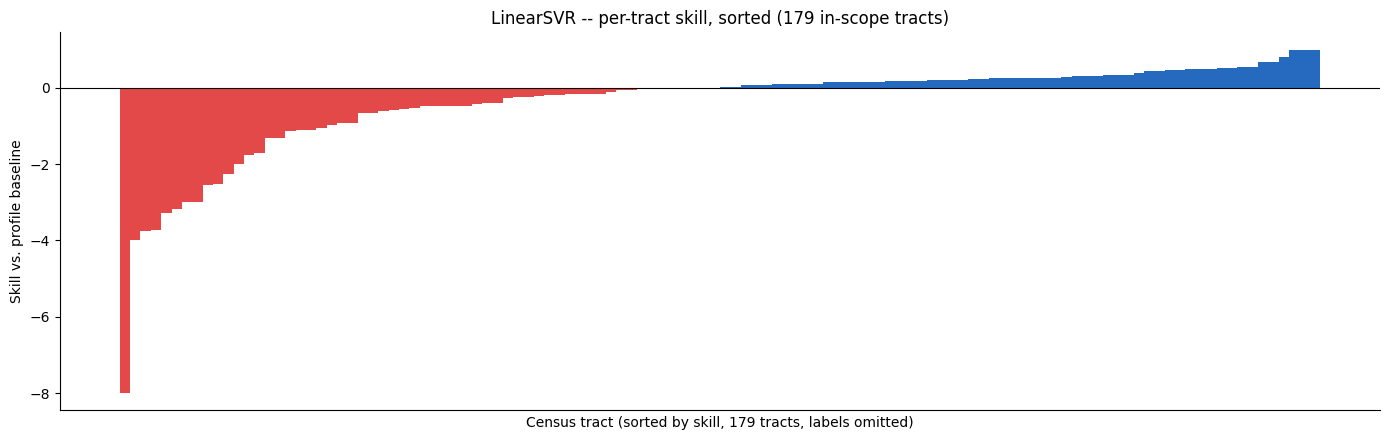

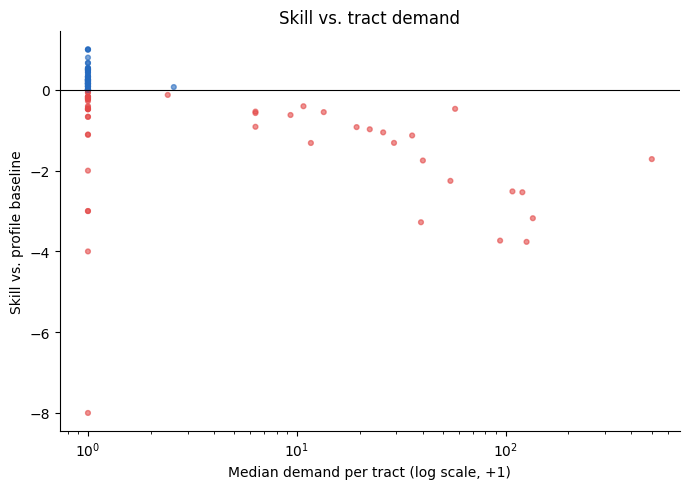

In [17]:
res_linear_tract_by_skill = res_linear_tract.sort_values("skill").reset_index(drop=True)
colors_skill_t = [SEQUENTIAL_BLUE if v >= 0 else "#e34948" for v in res_linear_tract_by_skill["skill"]]

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.bar(range(len(res_linear_tract_by_skill)), res_linear_tract_by_skill["skill"], color=colors_skill_t, width=1.0)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks([])
ax.set_xlabel(f"Census tract (sorted by skill, {len(res_linear_tract_by_skill)} tracts, labels omitted)")
ax.set_ylabel("Skill vs. profile baseline")
ax.set_title("LinearSVR -- per-tract skill, sorted (179 in-scope tracts)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

res_linear_tract_ranked = res_linear_tract.merge(
    TRACT_MEDIAN_DEMAND, left_on="tract_id", right_index=True
)
colors_tract = [SEQUENTIAL_BLUE if v >= 0 else "#e34948" for v in res_linear_tract_ranked["skill"]]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(res_linear_tract_ranked["median_demand"] + 1, res_linear_tract_ranked["skill"], color=colors_tract, s=12, alpha=0.6)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xscale("log")
ax.set_xlabel("Median demand per tract (log scale, +1)")
ax.set_ylabel("Skill vs. profile baseline")
ax.set_title("Skill vs. tract demand")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Per-tract skill map for `LinearSVR`, at the 179 in-scope tracts (out of 878 -- compare
against 5.1.1's scope map to see which community areas these sit within).

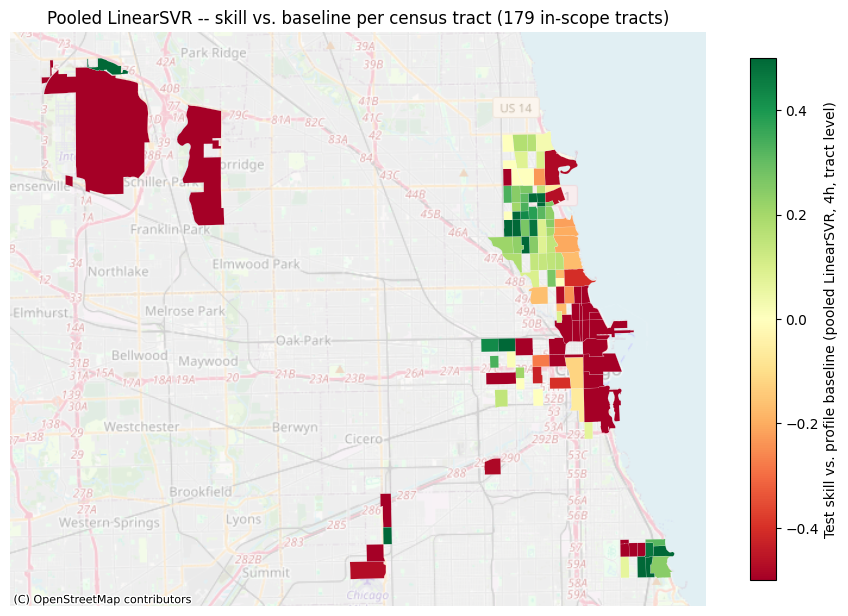

In [18]:
gdf_skill_tract = tracts_gdf[["tract_id", "geometry"]].merge(
    res_linear_tract[["tract_id", "skill"]], on="tract_id", how="left",
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(9, 9))
gdf_skill_tract.plot(ax=ax, column="skill", cmap="RdYlGn", vmin=-0.5, vmax=0.5, legend=True,
                     legend_kwds={"label": "Test skill vs. profile baseline (pooled LinearSVR, 4h, tract level)", "shrink": 0.6},
                     edgecolor="white", linewidth=0.1)
ctx.add_basemap(ax, crs=gdf_skill_tract.crs, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.35)
ax.set_title("Pooled LinearSVR -- skill vs. baseline per census tract (179 in-scope tracts)")
ax.axis("off")
plt.tight_layout()
plt.show()

### 5.7.2 Top 3 Tracts — All Models

Actual vs. both models for the top-3 tracts (by median demand), same eval week and
`test_plot_t`/`top_3_tracts` as 5.4.1 -- now with `LinearSVR` overlaid too, not just the
baseline. Top-3 only, same reasoning as 5.4.1 (bottom-3 tracts are too close to zero to be
informative here).

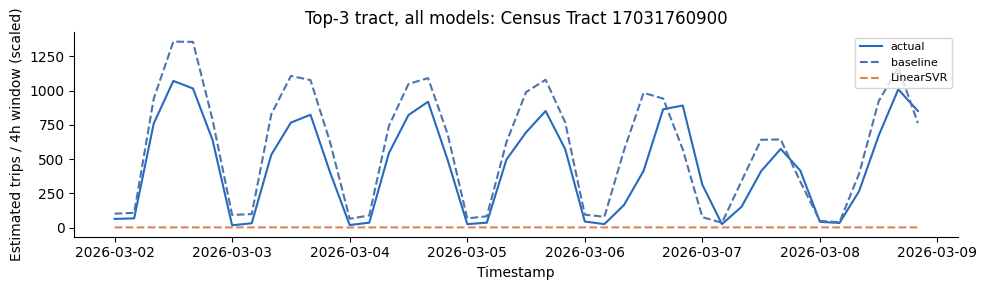

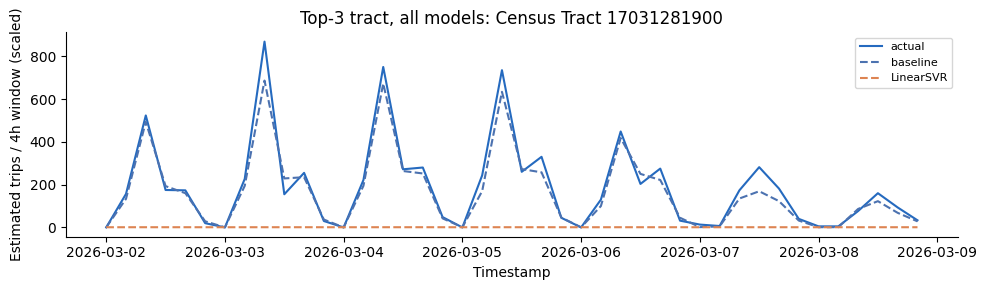

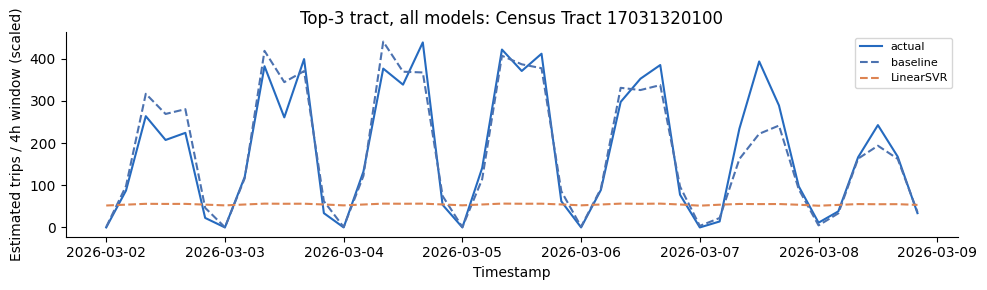

In [19]:
# Same test_plot_t/eval_mask_t/top_3_tracts as 5.4.1 -- slice LinearSVR's predictions the same way.
test_plot_pred_linear_t = y_pred_linear_tract[eval_mask_t.to_numpy()]

TRACT_MODEL_COLORS = ["#4C72B0", "#DD8452"]  # first two of 03.02's categorical palette, for consistency

for tract in top_3_tracts:
    mask = (test_plot_t["tract_id"] == tract).to_numpy()
    area_val = test_plot_t[mask]

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(area_val["timestamp"], area_val["count"], label="actual", color=SEQUENTIAL_BLUE)
    ax.plot(area_val["timestamp"], test_plot_pred_base_t[mask], label="baseline", color=TRACT_MODEL_COLORS[0], linestyle="--")
    ax.plot(area_val["timestamp"], test_plot_pred_linear_t[mask], label="LinearSVR", color=TRACT_MODEL_COLORS[1], linestyle="--")
    ax.set_title(f"Top-3 tract, all models: Census Tract {tract}")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Estimated trips / 4h window (scaled)")
    ax.legend(loc="upper right", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

## 6. Export Results

Append this run's two models (profile baseline, pooled `LinearSVR`) to the shared results
CSVs -- the same `model_results_summary.csv` and `model_results_by_area.csv` `03.01`/`03.02`
write to, distinguished by `spatial_resolution="census_tract"`, so all resolutions and both
model families end up comparable in one place. `relative_mae` isn't computed at this
resolution (no `relative_mae()` helper here, unlike the community-area notebooks) and neither
model's fit time is captured in a variable -- both are left blank rather than estimated.
Reruns overwrite this notebook's own prior rows (matched on model + notebook + resolution)
rather than duplicating them.

In [21]:
import pathlib
RESULTS_DIR = pathlib.Path("../../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_CSV = RESULTS_DIR / "model_results_summary.csv"
DETAIL_CSV  = RESULTS_DIR / "model_results_by_area.csv"
NOTEBOOK_NAME = "03_prediction_svm_tract.ipynb"


def upsert_csv(df_new, path, key_cols):
    """Append df_new to the CSV at `path`, replacing any existing rows with the same key_cols
    (so reruns update in place instead of duplicating) -- creates the file if it doesn't exist."""
    if path.exists():
        df_old = pd.read_csv(path)
        old_keys = df_old[key_cols].apply(tuple, axis=1)
        new_keys = set(df_new[key_cols].apply(tuple, axis=1))
        df_out = pd.concat([df_old[~old_keys.isin(new_keys)], df_new], ignore_index=True)
    else:
        df_out = df_new
    df_out.to_csv(path, index=False)
    return df_out


run_timestamp = pd.Timestamp.now().isoformat(timespec="seconds")

# (label, pooled metrics, per-tract results, weighted RMSE, demand-weighted skill, median
# skill) -- both models cover all 179 in-scope tracts, so they share y_true_tract/
# TEST_TRACT_UNIT_WEIGHTS for weighted_rmse.
tract_models = [
    ("Profile baseline (tract)", pm_baseline_tract, baseline_results_tract,
     weighted_rmse(y_true_tract, baseline_y_pred_tract, TEST_TRACT_UNIT_WEIGHTS), 0.0, 0.0),
    ("LinearSVR (full data, no kernel)", pm_linear_tract, res_linear_tract,
     weighted_rmse(y_true_tract, y_pred_linear_tract, TEST_TRACT_UNIT_WEIGHTS),
     weighted_skill_vs_baseline(res_linear_tract, baseline_df=baseline_results_tract,
                                 median_demand=TRACT_MEDIAN_DEMAND, group_col="tract_id"),
     res_linear_tract["skill"].median()),
]

summary_rows, detail_rows = [], []
for model_name, pm, res_df, wrmse, skill_w, skill_med in tract_models:
    summary_rows.append({
        "model_name": model_name,
        "notebook": NOTEBOOK_NAME,
        "spatial_resolution": "census_tract",
        "temporal_resolution": FREQ,
        "n_units": len(ALL_TRACTS),
        "train_start": DATA_START.date().isoformat(),
        "train_end": (TRAIN_END - pd.Timedelta(days=1)).date().isoformat(),
        "test_start": TRAIN_END.date().isoformat(),
        "test_end": (DATA_END_EXCL - pd.Timedelta(days=1)).date().isoformat(),
        "rmse": pm["rmse"],
        "mae": pm["mae"],
        "r2": pm["r2"],
        "weighted_rmse": wrmse,
        "skill_demand_weighted": round(float(skill_w), 4),
        "skill_median": round(float(skill_med), 4),
        "fit_time_s": None,
        "last_run_at": run_timestamp,
    })
    for _, row in res_df.iterrows():
        detail_rows.append({
            "model_name": model_name,
            "notebook": NOTEBOOK_NAME,
            "spatial_resolution": "census_tract",
            "temporal_resolution": FREQ,
            "unit_id": int(row["tract_id"]),
            "median_demand": TRACT_MEDIAN_DEMAND.get(row["tract_id"]),
            "rmse": row["rmse"],
            "mae": row["mae"],
            "r2": row["r2"],
            "skill": row.get("skill", 0.0),
            "relative_mae": None,
            "last_run_at": run_timestamp,
        })

summary_df = pd.DataFrame(summary_rows)
detail_df = pd.DataFrame(detail_rows)

upsert_csv(summary_df, SUMMARY_CSV,
           key_cols=["model_name", "notebook", "spatial_resolution", "temporal_resolution"])
upsert_csv(detail_df, DETAIL_CSV,
           key_cols=["model_name", "notebook", "spatial_resolution", "temporal_resolution", "unit_id"])

print(f"Wrote {len(summary_df)} rows to {SUMMARY_CSV}")
print(f"Wrote {len(detail_df)} rows to {DETAIL_CSV}")
summary_df

/Users/maikekatterbach/Documents/GitHub/AAA_Team_1/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:592: RuntimeWarning: invalid value encountered in multiply
  avg = avg_as_array = np.multiply(a, wgt,


Wrote 2 rows to ../../results/model_results_summary.csv
Wrote 358 rows to ../../results/model_results_by_area.csv


,model_name,notebook,spatial_resolution,temporal_resolution,n_units,train_start,train_end,test_start,test_end,rmse,mae,r2,weighted_rmse,skill_demand_weighted,skill_median,fit_time_s,last_run_at
0,Profile baseline (tract),03_prediction_svm_tract.ipynb,census_tract,4h,179,2024-01-01,2025-12-31,2026-01-01,2026-05-31,25.18,5.63,0.8599,132.826922,0.0,0.0000,None,2026-07-18T14:51:15
1,"LinearSVR (full data, no kernel)",03_prediction_svm_tract.ipynb,census_tract,4h,179,2024-01-01,2025-12-31,2026-01-01,2026-05-31,66.39,13.12,0.0257,355.192245,NaN,-0.2588,None,2026-07-18T14:51:15


## 7. Shortfalls & Honest Limitations

- **Scope cut to 11 of 77 community areas** (5.0): tract-precision data is too sparse
  elsewhere to model at all -- a data-availability ceiling, not a modeling choice. `03.02`
  is the fallback for the other 66 areas.
- **Scaled counts are estimates, not observations** (5.2): the `1/retention_frac` correction
  assumes tract-precision trips are representative within each included area -- if masking
  is systematically biased toward certain hours or tracts, the scaling won't catch it.
- **Pooled LinearSVR collapses to a per-tract constant, underperforming the baseline**
  (5.5.1, 5.7.2): GMM hotspot-distance features carry 99.6% of total |coefficient| mass
  despite being 6/25 = 24% of continuous features -- time/calendar and weather are
  effectively zero. The top-3 tract charts show LinearSVR predicting flat near-zero
  across the whole eval week while actual/baseline trace the daily cycle -- the model is
  learning *which tract* rather than *what is happening now*. Net effect: pooled
  R2=0.026 vs. baseline's 0.860, weighted RMSE 355 vs. 133, and 90 of 179 tracts have
  negative skill. Same pooling-loses-to-baseline pattern as `03.01`, but far more severe --
  more units (179 vs. 77) means between-tract variance dominates the loss even harder,
  and hotspot distance gives the optimizer an easier per-tract shortcut to lean on.
- **No kernel comparison beyond the documentation-only snapshot** (5.6), and no per-area or
  demand-tiered variants -- same reasoning as `03.02`, at even smaller scale per unit.

## 8. Outlook

- Results feed the SVM section of the report (`sections/04-prediction_svm.qmd`), alongside
  `03.01` and `03.02`.
- The 66 excluded community areas remain covered only at `03.02`'s resolution -- a
  genuinely tract-precise model for them isn't possible without richer location data than
  the portal provides.